In [ ]:
import requests
import os
from dotenv import load_dotenv
from langchain_groq import ChatGroq

load_dotenv()

groq_key = os.environ["GROQ_API_KEY"]
os.environ['LANGCHAIN_API_KEY'] = os.getenv('LANGCHAIN_API_KEY')
W_API_KEY = os.getenv('WEATHER_API_KEY')

llm = ChatGroq(model="openai/gpt-oss-20b", groq_api_key=groq_key)

In [ ]:
# defining `get_weather` tool

def get_weather(city:str):
    # doc strings play an important role, it make the tool understable to the LLM
    # The LLM now knows that by using this tool, it can get real time info of any city's weather
    """Get the current weather details of a city"""

    url = f"https://api.openweathermap.org/geo/1.0/direct?q={city}&appid={W_API_KEY}"

    geo_details = requests.get(url)

    lat = geo_details.json()[0]['lat']
    lon = geo_details.json()[0]['lon']

    w_url = f"https://api.openweathermap.org/data/2.5/weather?lat={lat}&lon={lon}&appid={W_API_KEY}&units=metric"

    response = requests.get(w_url)
    return response.json()

In [116]:
llm_with_tool = llm.bind_tools([get_weather])
llm_with_tool

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.1', 'langchain': '1.3.18'}}, profile={'name': 'GPT OSS 20B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x0000023EBBE18250>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000023EBBE1E5D0>, model_name='openai/gpt-oss-20b', model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'get_weather', 'description': 'Get the current weather details of a city', 'parameters': {'

In [117]:
res = llm_with_tool.invoke("what is the weather in London?")

In [118]:
print(res.tool_calls)
print(res.additional_kwargs['reasoning_content'])

print(res.content, "\n# the response is empty")

[{'name': 'get_weather', 'args': {'city': 'London'}, 'id': 'fc_5b3ce72a-f0ec-41e2-a174-85f7bba5a69b', 'type': 'tool_call'}]
We need to call the get_weather function.
 
# the response is empty


In [119]:
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages:Annotated[list[AnyMessage], add_messages]

In [120]:
def llm_tools(state:State):
    return {"messages": [llm_with_tool.invoke(state['messages'])]}

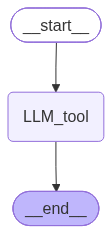

In [121]:
from IPython.display import display, Image
from langgraph.graph import START, END, StateGraph

graph_build = StateGraph(State)

graph_build.add_node("LLM_tool", llm_tools)

graph_build.add_edge(START, "LLM_tool")
graph_build.add_edge("LLM_tool", END)

graph = graph_build.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [122]:
res = graph.invoke({"messages": "What is the weather in paris right now?"})
res

{'messages': [HumanMessage(content='What is the weather in paris right now?', additional_kwargs={}, response_metadata={}, id='c769b58f-95f5-41f6-80fd-78b3f2ac7fee'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to call function get_weather with city "Paris".', 'tool_calls': [{'id': 'fc_5791ca6b-3698-432b-88a3-531d38ced4b2', 'function': {'arguments': '{"city":"Paris"}', 'name': 'get_weather'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 36, 'prompt_tokens': 131, 'total_tokens': 167, 'completion_time': 0.039338421, 'completion_tokens_details': {'reasoning_tokens': 13}, 'prompt_time': 0.011543759, 'prompt_tokens_details': None, 'queue_time': 0.623112321, 'total_time': 0.05088218}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_d3e146e1a5', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a06c21-9ce8-7e41-88c3-0900f6b8c781-0', tool_calls=[{'nam

In [123]:
res['messages'][-1].tool_calls

[{'name': 'get_weather',
  'args': {'city': 'Paris'},
  'id': 'fc_5791ca6b-3698-432b-88a3-531d38ced4b2',
  'type': 'tool_call'}]

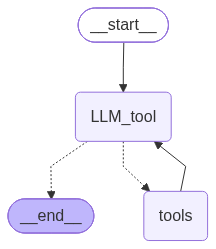

In [ ]:
from langgraph.prebuilt import ToolNode, tools_condition

graph_build = StateGraph(State)

graph_build.add_node("LLM_tool", llm_tools)
graph_build.add_node("tools", ToolNode([get_weather]))

graph_build.add_edge(START, "LLM_tool")
# connecting the `get_weather` tool to it
graph_build.add_conditional_edges("LLM_tool", tools_condition)
graph_build.add_edge("tools", "LLM_tool")

graph = graph_build.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
res = graph.invoke({"messages": "What is the weather in Kolkata right now?"})
print(res['messages'][-1].content)

# with the help of weather tool, it can access real time weather now.

Here’s the current weather snapshot for Kolkata (as of the latest update):

| **Parameter**          | **Value**                                   |
|------------------------|---------------------------------------------|
| **Temperature**        | 30.96 °C (≈ 86 °F)                           |
| **Feels‑Like**         | 37.96 °C (≈ 100 °F)                          |
| **Weather**            | Light rain – “Rain” (cloudy, 78 % cloud cover) |
| **Humidity**           | 74 %                                         |
| **Wind**               | 4.63 m/s from the south (180°)               |
| **Rainfall**           | 0.22 mm in the last hour                     |
| **Visibility**         | 10 km (10,000 m)                             |
| **Pressure**           | 1004 hPa                                    |

**Quick takeaway:** It’s currently a warm, humid day with a light drizzle and a slight breeze from the south. If you’re heading out, a light jacket or an umbrella would be handy!
